Dataset load ho raha hai... (is mein kuch seconds lag sakte hain)


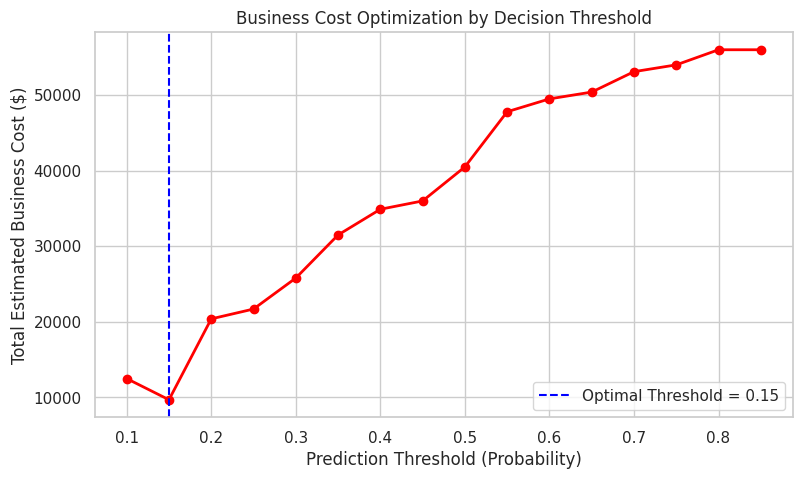


--- Business Insight ---
Agar bank default ka faisla 15% probability par kare, toh nuqsan sab se kam hoga.

--- Final Confusion Matrix at Optimal Threshold ---
[[54 87]
 [ 1 58]]


In [1]:
# --- ADVANCED TASK 4: LOAN DEFAULT RISK WITH BUSINESS COST OPTIMIZATION ---
# Objective: Predict loan default likelihood and optimize decision threshold based on cost.

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.datasets import fetch_openml

# 2. LOAD DATASET
print("Dataset load ho raha hai... (is mein kuch seconds lag sakte hain)")
# Hum OpenML ka built-in credit dataset use kar rahe hain taake download ka masla na ho
credit_data = fetch_openml(name='credit-g', version=1, as_frame=True, parser='auto')
df = credit_data.frame

# Target variable ko numbers mein convert karein ('bad' credit = 1 i.e., Default, 'good' = 0)
df['target'] = df['class'].apply(lambda x: 1 if x == 'bad' else 0)
df = df.drop(columns=['class'])

# 3. DATA CLEANING & PREPROCESSING
# Text (Categorical) columns ko numbers mein badalna
le = LabelEncoder()
for col in df.select_dtypes(include=['category', 'object']).columns:
    df[col] = le.fit_transform(df[col])

# Data ko X (Features) aur y (Target) mein split karein
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression ke liye data ko scale (normalize) karna zaroori hai
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. TRAIN BINARY CLASSIFICATION MODEL
# Instructions ke mutabiq Logistic Regression use kar rahe hain
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# 5. BUSINESS COST OPTIMIZATION (Threshold Adjustment)
# Bank ke liye cost/nuqsan define karte hain:
cost_FP = 100   # False Positive Cost: Profit miss hua (e.g., $100)
cost_FN = 1000  # False Negative Cost: Asal loan doob gaya (e.g., $1000)

y_probs = model.predict_proba(X_test_scaled)[:, 1] # Sirf default karne ki probabilities lein
thresholds = np.arange(0.1, 0.9, 0.05)
costs = []

# Har threshold check karein ke kis par nuqsan sab se kam hai
for thresh in thresholds:
    y_pred_thresh = (y_probs >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_thresh)

    # cm[0][1] = False Positives, cm[1][0] = False Negatives
    FP = cm[0][1]
    FN = cm[1][0]
    total_cost = (FP * cost_FP) + (FN * cost_FN)
    costs.append(total_cost)

# Sab se kam cost (Minimum) wala threshold dhoondein
min_cost_index = np.argmin(costs)
best_threshold = thresholds[min_cost_index]

# 6. VISUALIZE COST OPTIMIZATION
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))
plt.plot(thresholds, costs, marker='o', color='red', linewidth=2)
plt.axvline(x=best_threshold, color='blue', linestyle='--', label=f'Optimal Threshold = {best_threshold:.2f}')
plt.title('Business Cost Optimization by Decision Threshold')
plt.xlabel('Prediction Threshold (Probability)')
plt.ylabel('Total Estimated Business Cost ($)')
plt.legend()
plt.show()

# 7. FINAL EVALUATION AT OPTIMAL THRESHOLD
print(f"\n--- Business Insight ---")
print(f"Agar bank default ka faisla {best_threshold*100:.0f}% probability par kare, toh nuqsan sab se kam hoga.")

y_pred_final = (y_probs >= best_threshold).astype(int)
print("\n--- Final Confusion Matrix at Optimal Threshold ---")
print(confusion_matrix(y_test, y_pred_final))